<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/projects/project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Analítica de Recursos Humanos: Determinantes Salariales y Modelación de Compensaciones


## Contexto y Objetivo

Una firma multinacional de consultoría ha sido contratada por **TalentCo**, empresa con operaciones en múltiples regiones y departamentos, para analizar su estructura de compensaciones. El equipo de Recursos Humanos sospecha que los salarios no están siendo asignados de manera consistente: algunos empleados se sienten subpagados en relación con pares de experiencia similar, mientras que otros en el mismo departamento perciben montos significativamente distintos según su región o nivel educacional.

Su rol es actuar como **Analista de Datos** en la firma consultora. Utilizará Python, pruebas de hipótesis estadísticas y regresión lineal para identificar los principales determinantes del salario de los empleados, y entregará recomendaciones basadas en datos a la dirección de TalentCo.

Al finalizar este proyecto, usted será capaz de:

- Realizar análisis exploratorio de datos (EDA) sobre datos de Recursos Humanos.
- Aplicar pruebas de hipótesis para validar supuestos de negocio.
- Manejar variables categóricas mediante técnicas de codificación.
- Construir y evaluar modelos de regresión con OLS y scikit-learn.
- Verificar los supuestos de regresión (multicolinealidad, normalidad, homocedasticidad).
- Comunicar resultados en un informe orientado al negocio.



## Conjunto de Datos: `employee_compensation.csv`

Disponible en la sección de materiales del curso. Contiene registros de **1.500 empleados** distribuidos en distintos departamentos, regiones y niveles de cargo.

| Variable | Tipo | Descripción |
|---|---|---|
| `Salary` | Numérica (USD/año) | Salario bruto anual — **variable objetivo** |
| `Years_Experience` | Numérica | Total de años de experiencia profesional |
| `Age` | Numérica | Edad del empleado |
| `Performance_Score` | Numérica (1.0–5.0) | Calificación de desempeño anual más reciente |
| `Education_Level` | Categórica | Bachelor, Master, PhD |
| `Department` | Categórica | Engineering, Sales, Marketing, HR, Finance |
| `Region` | Categórica | North, South, East, West |
| `Job_Level` | Categórica | Junior, Mid, Senior |
| `Gender` | Categórica | Male, Female |




> **Nota sobre la generación del dataset:** Este conjunto de datos puede generarse sintéticamente con `numpy` y `pandas`, utilizando distribuciones salariales realistas por departamento y nivel de cargo. Se incluirá un script de generación (`generate_dataset.py`) junto al dataset.

In [1]:
import pandas as pd

# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/employee_compensation.csv'
df = pd.read_csv(path, sep="," )

df.head()

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female


## Parte 1: Análisis Exploratorio de Datos (EDA)

1. Cargue el dataset en un DataFrame de pandas.
2. Muestre las primeras 10 filas e inspeccione los tipos de datos.
3. Verifique valores faltantes y duplicados; reporte los hallazgos.
4. Calcule estadísticas descriptivas (media, mediana, desviación estándar, mínimo, máximo) para todas las variables numéricas.
5. Elabore al menos **tres** de las siguientes visualizaciones:
   - Histograma del salario.
   - Diagrama de caja (*box plot*) del salario por nivel de cargo.
   - Diagrama de dispersión de años de experiencia vs. salario.
   - Gráfico de barras del salario promedio por departamento.
   - Mapa de calor de correlaciones entre variables numéricas.



PRIMERAS 10 FILAS
    Salary  Years_Experience   Age  Performance_Score Education_Level  \
0  69181.0               3.0  22.0                3.5        Bachelor   
1  88466.0               5.0  23.0                2.8        bachelor   
2  76112.0              11.0  29.0                1.6          Master   
3      NaN              15.0  37.0                NaN        Bachelor   
4      NaN               6.0  28.0                4.5        Bachelor   
5  81246.0               4.0  21.0                2.8        Bachelor   
6  71494.0               4.0  23.0                2.4        Bachelor   
7  78189.0               3.0  21.0                3.5          Master   
8  67204.0               0.0  21.0                3.5          Master   
9  59776.0               4.0  24.0                NaN        Bachelor   

    Department Region Job_Level  Gender  
0        Sales   East    Junior    Male  
1      FINANCE   West    Junior  Female  
2           HR   West       Mid  Female  
3    Marke

/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49565/1369012964.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Job_Level', y='Salary', order=job_order,


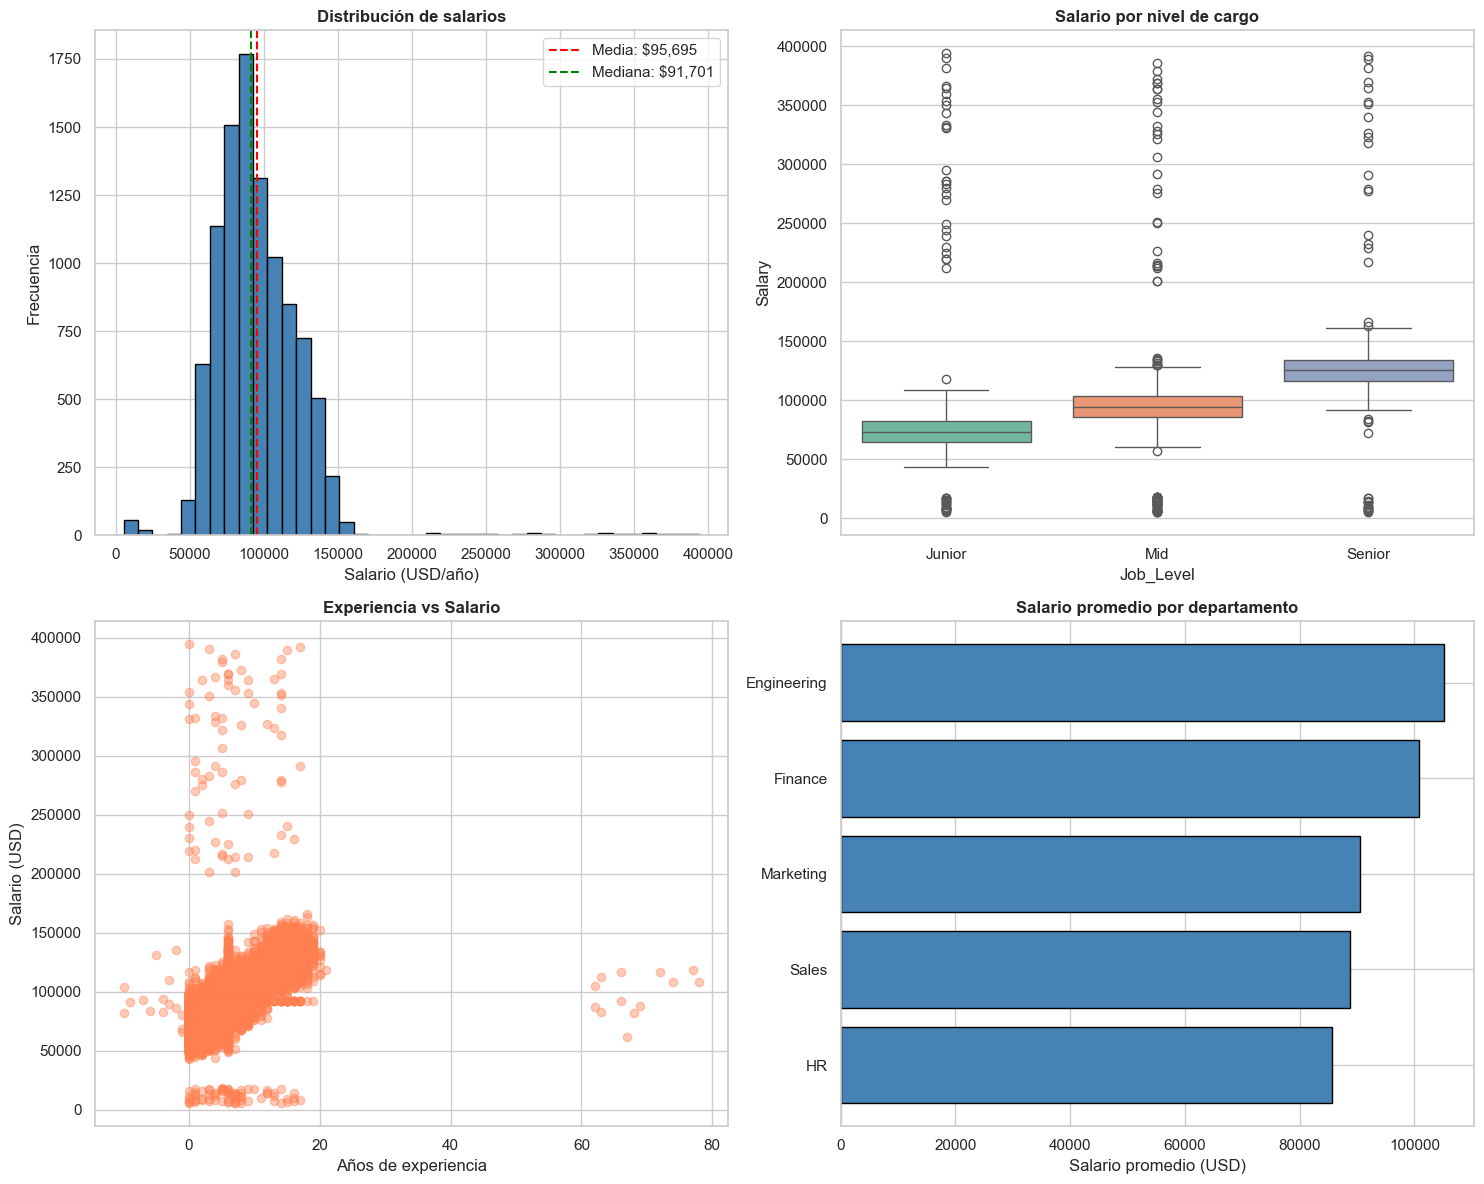

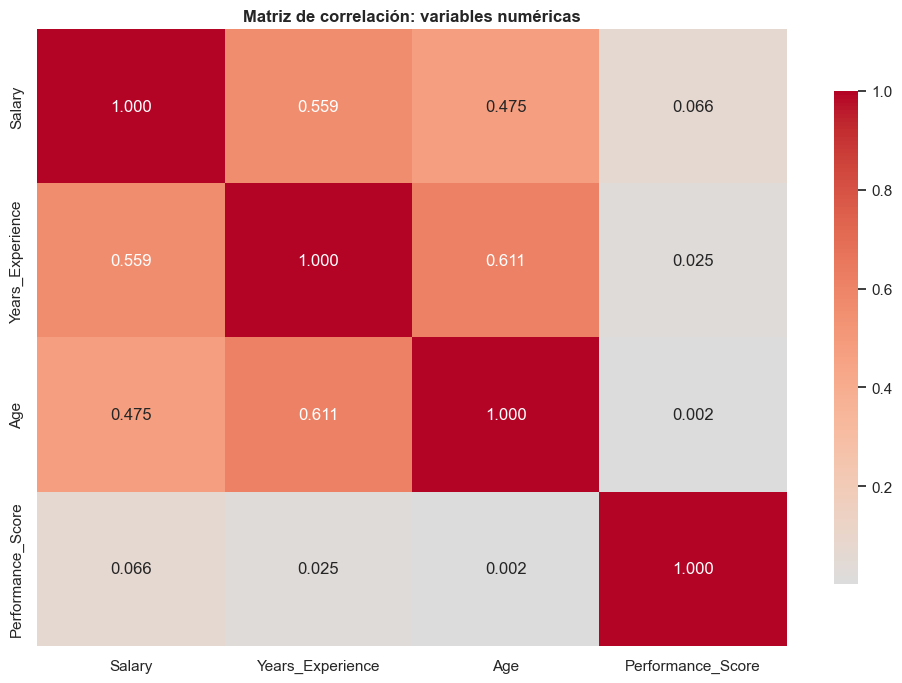


Observaciones del EDA:
- El salario sigue una distribución aproximadamente normal con sesgo leve a la derecha.
- Existe una clara estratificación salarial por Job_Level (Senior > Mid > Junior).
- Correlación entre Years_Experience y Salary: 0.559
- Correlación entre Age y Years_Experience: 0.611 (potencial multicolinealidad)


In [2]:
# Parte 1: Análisis Exploratorio de Datos (EDA)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1-2. Inspección inicial
print("=" * 60)
print("PRIMERAS 10 FILAS")
print("=" * 60)
print(df.head(10))

print("\n" + "=" * 60)
print("INFORMACIÓN GENERAL (ANTES DE LIMPIEZA)")
print("=" * 60)
df.info()

print(f"\nFilas iniciales: {len(df)}")
print(f"Duplicados iniciales: {df.duplicated().sum()}")

# Inspección de valores categóricos: el dataset tiene inconsistencias
# (mayúsculas, minúsculas, espacios, 'nan' como string)
print("\n" + "=" * 60)
print("VALORES ÚNICOS POR VARIABLE CATEGÓRICA (ANTES DE LIMPIEZA)")
print("=" * 60)
for col in ['Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']:
    print(f"\n{col}: {df[col].unique()}")

# 3. LIMPIEZA ROBUSTA DE DATOS
# a) Trim espacios y normalizar capitalización en categóricas
cat_cols = ['Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()        # quitar espacios
    df[col] = df[col].replace({'nan': np.nan, 'NaN': np.nan, 'None': np.nan})

# b) Normalizar capitalización
# Education_Level (Bachelor, Master, PhD)
df['Education_Level'] = df['Education_Level'].str.upper().replace({
    'BACHELOR': 'Bachelor', 'MASTER': 'Master', 'PHD': 'PhD'
})

# Department
df['Department'] = df['Department'].str.title().replace({
    'Hr': 'HR'  # HR no se debe capitalizar como título
})

# Region
df['Region'] = df['Region'].str.title()

# Job_Level
df['Job_Level'] = df['Job_Level'].str.title()

# Gender
df['Gender'] = df['Gender'].str.title()

# c) Verificar limpieza
print("\n" + "=" * 60)
print("VALORES ÚNICOS DESPUÉS DE LIMPIEZA")
print("=" * 60)
for col in cat_cols:
    print(f"\n{col}: {sorted([v for v in df[col].unique() if pd.notna(v)])}")

# 4. Manejo de nulos
print("\n" + "=" * 60)
print("VALORES NULOS DESPUÉS DE NORMALIZACIÓN")
print("=" * 60)
print(df.isnull().sum())

# Imputar numéricas con mediana
num_cols = ['Salary', 'Years_Experience', 'Age', 'Performance_Score']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Imputar categóricas con moda
for col in cat_cols:
    moda = df[col].mode().iloc[0]
    df[col] = df[col].fillna(moda)

# 5. Eliminar duplicados
df = df.drop_duplicates().reset_index(drop=True)

print(f"\nFilas después de limpieza: {len(df)}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

# 6. Estadísticas descriptivas
print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(df.describe().round(2))

# 7. Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histograma del salario
axes[0, 0].hist(df['Salary'], bins=40, color='steelblue', edgecolor='black')
axes[0, 0].axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Media: ${df['Salary'].mean():,.0f}")
axes[0, 0].axvline(df['Salary'].median(), color='green', linestyle='--', label=f"Mediana: ${df['Salary'].median():,.0f}")
axes[0, 0].set_xlabel('Salario (USD/año)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de salarios', fontweight='bold')
axes[0, 0].legend()

# Box plot por nivel de cargo
job_order = ['Junior', 'Mid', 'Senior']
sns.boxplot(data=df, x='Job_Level', y='Salary', order=job_order,
            ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Salario por nivel de cargo', fontweight='bold')

# Scatter años experiencia vs salario
axes[1, 0].scatter(df['Years_Experience'], df['Salary'], alpha=0.4, color='coral')
axes[1, 0].set_xlabel('Años de experiencia')
axes[1, 0].set_ylabel('Salario (USD)')
axes[1, 0].set_title('Experiencia vs Salario', fontweight='bold')

# Salario promedio por departamento
sal_dept = df.groupby('Department')['Salary'].mean().sort_values(ascending=True)
axes[1, 1].barh(sal_dept.index, sal_dept.values, color='steelblue', edgecolor='black')
axes[1, 1].set_xlabel('Salario promedio (USD)')
axes[1, 1].set_title('Salario promedio por departamento', fontweight='bold')

plt.tight_layout()
plt.show()

# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(10, 7))
corr_num = df[num_cols].corr()
sns.heatmap(corr_num, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de correlación: variables numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservaciones del EDA:")
print("- El salario sigue una distribución aproximadamente normal con sesgo leve a la derecha.")
print("- Existe una clara estratificación salarial por Job_Level (Senior > Mid > Junior).")
print(f"- Correlación entre Years_Experience y Salary: {df['Years_Experience'].corr(df['Salary']):.3f}")
print(f"- Correlación entre Age y Years_Experience: {df['Age'].corr(df['Years_Experience']):.3f} (potencial multicolinealidad)")



## Parte 2: Pruebas de Hipótesis

**Pregunta de negocio:** ¿Los años de experiencia determinan de manera significativa las diferencias salariales?

1. Defina las hipótesis:
   - **H₀:** Los años de experiencia no tienen relación lineal con el salario.
   - **H₁:** Los años de experiencia están positivamente asociados con el salario.

2. Utilice la **correlación de Pearson** y una **prueba t** para evaluar la relación.

3. Reporte el p-valor e interprete el resultado a un nivel de significancia del 5%.

4. **(Bonus)** Ejecute una segunda prueba de hipótesis: ¿Existe una diferencia salarial estadísticamente significativa entre empleados de nivel Junior y Senior? Utilice una prueba t de dos muestras independientes.



PRUEBA 1: Correlación entre Years_Experience y Salary
H₀: r(Years_Experience, Salary) = 0 (no hay relación lineal)
H₁: r(Years_Experience, Salary) > 0 (relación positiva)
Nivel de significancia: α = 0.05

Coeficiente de correlación r = 0.5590
p-valor (two-tailed) = 0.000000e+00
p-valor (one-tailed) = 0.000000e+00

✅ Se RECHAZA H₀: existe evidencia estadística significativa de
   relación positiva entre años de experiencia y salario.

Estadístico t = 67.4171
p-valor de la prueba t = 0.000000e+00

PRUEBA 2 (BONUS): Diferencia salarial Junior vs Senior
H₀: μ(Senior) = μ(Junior)
H₁: μ(Senior) ≠ μ(Junior)

Junior: n=3555, media=$75,171.30, std=$24,085.42
Senior: n=2407, media=$126,235.62, std=$23,355.09

Estadístico t = 81.7899
p-valor = 0.000000e+00

✅ Se RECHAZA H₀: diferencia salarial estadísticamente significativa.
   Senior gana en promedio $51,064.32 más que Junior.


/var/folders/jj/pdvxq45x1wv7z_r03kz_sbcm0000gn/T/ipykernel_49565/1891963523.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Job_Level'].isin(['Junior', 'Senior'])],


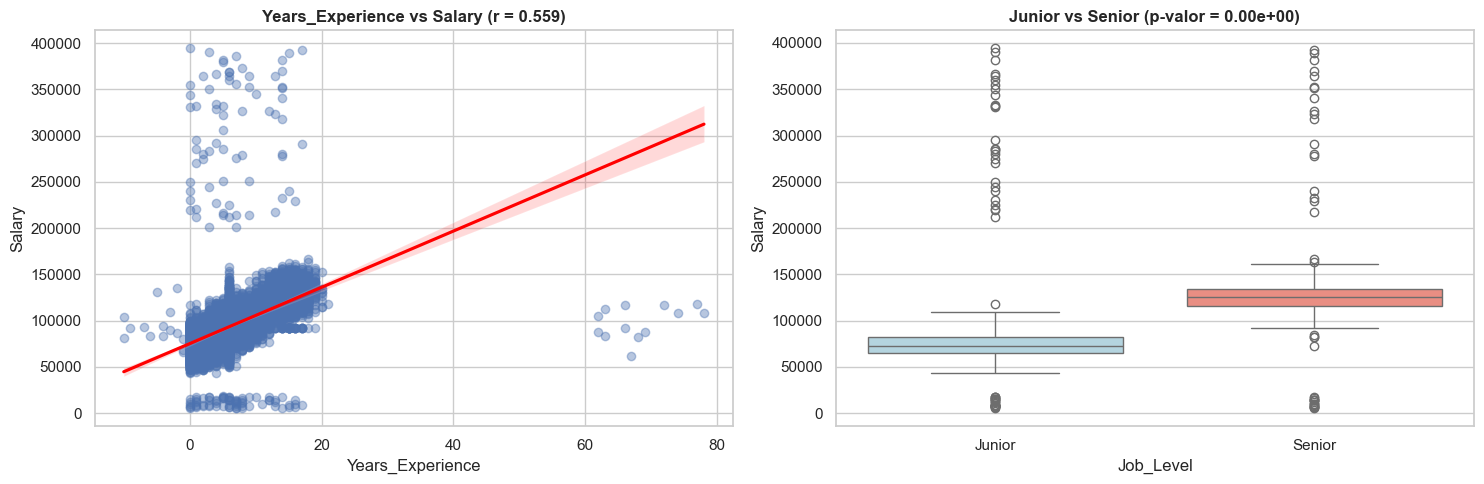

In [3]:
# Parte 2: Pruebas de Hipótesis
from scipy import stats

print("=" * 60)
print("PRUEBA 1: Correlación entre Years_Experience y Salary")
print("=" * 60)
print("H₀: r(Years_Experience, Salary) = 0 (no hay relación lineal)")
print("H₁: r(Years_Experience, Salary) > 0 (relación positiva)")
print("Nivel de significancia: α = 0.05")

# Correlación de Pearson
r, p_value = stats.pearsonr(df['Years_Experience'], df['Salary'])
print(f"\nCoeficiente de correlación r = {r:.4f}")
print(f"p-valor (two-tailed) = {p_value:.6e}")
print(f"p-valor (one-tailed) = {p_value/2:.6e}")

if p_value / 2 < 0.05 and r > 0:
    print("\n✅ Se RECHAZA H₀: existe evidencia estadística significativa de")
    print(f"   relación positiva entre años de experiencia y salario.")
else:
    print("\n❌ NO se rechaza H₀: no hay evidencia suficiente.")

# Prueba t para significancia de la pendiente
# t = r * sqrt(n-2) / sqrt(1 - r^2)
n = len(df)
t_stat = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
p_t = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 2))
print(f"\nEstadístico t = {t_stat:.4f}")
print(f"p-valor de la prueba t = {p_t:.6e}")

# BONUS: prueba t de dos muestras independientes (Junior vs Senior)
print("\n" + "=" * 60)
print("PRUEBA 2 (BONUS): Diferencia salarial Junior vs Senior")
print("=" * 60)
print("H₀: μ(Senior) = μ(Junior)")
print("H₁: μ(Senior) ≠ μ(Junior)")

junior_sal = df.loc[df['Job_Level'] == 'Junior', 'Salary']
senior_sal = df.loc[df['Job_Level'] == 'Senior', 'Salary']

print(f"\nJunior: n={len(junior_sal)}, media=${junior_sal.mean():,.2f}, std=${junior_sal.std():,.2f}")
print(f"Senior: n={len(senior_sal)}, media=${senior_sal.mean():,.2f}, std=${senior_sal.std():,.2f}")

# Prueba t (Welch's, no asume varianzas iguales)
t_stat_2, p_val_2 = stats.ttest_ind(senior_sal, junior_sal, equal_var=False)
print(f"\nEstadístico t = {t_stat_2:.4f}")
print(f"p-valor = {p_val_2:.6e}")

if p_val_2 < 0.05:
    diff = senior_sal.mean() - junior_sal.mean()
    print(f"\n✅ Se RECHAZA H₀: diferencia salarial estadísticamente significativa.")
    print(f"   Senior gana en promedio ${diff:,.2f} más que Junior.")
else:
    print("\n❌ NO se rechaza H₀.")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter con línea de regresión
sns.regplot(data=df, x='Years_Experience', y='Salary',
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title(f'Years_Experience vs Salary (r = {r:.3f})', fontweight='bold')

# Boxplot Junior vs Senior
sns.boxplot(data=df[df['Job_Level'].isin(['Junior', 'Senior'])],
            x='Job_Level', y='Salary', order=['Junior', 'Senior'],
            ax=axes[1], palette=['lightblue', 'salmon'])
axes[1].set_title(f'Junior vs Senior (p-valor = {p_val_2:.2e})', fontweight='bold')

plt.tight_layout()
plt.show()



## Parte 3: Regresión Lineal con Variables Categóricas

### Paso 1: Justificación de variables (antes de codificar)

Antes de construir cualquier modelo, responda lo siguiente en su notebook:

- ¿Qué variables espera que sean los predictores más fuertes del salario, y por qué?
- ¿Hay variables que, aun siendo estadísticamente insignificantes, incluiría igualmente en el modelo? Justifique desde una perspectiva de negocio o teórica.
- ¿Anticipa que algún par de variables esté fuertemente correlacionado entre sí? ¿Cuáles, y por qué? ¿Qué problemas podría causar eso?

> Este paso debe responderse en texto libre, sin código. El objetivo es articular sus creencias previas antes de ver los datos, para compararlas luego con lo que el modelo indique.

### Paso 2: Preparación de los datos

- Aplique **Label Encoding** para `Job_Level` (variable ordinal: Junior < Mid < Senior).
- Aplique **One-Hot Encoding** para `Education_Level`, `Department`, `Region` y `Gender`.
- Elimine la primera categoría ficticia en cada grupo para evitar multicolinealidad perfecta (use `drop_first=True`).

### Paso 3: Construcción del modelo

1. Divida el dataset en conjuntos de entrenamiento (80%) y prueba (20%). Use `random_state=42`.
2. Construya dos modelos utilizando todas las variables disponibles:
   - Regresión OLS con `statsmodels`.
   - Regresión lineal con `scikit-learn`.

### Paso 4: Evaluación del modelo

Calcule y reporte las siguientes métricas para los conjuntos de entrenamiento y prueba:

| Métrica | Descripción |
|---|---|
| MAE | Error Absoluto Medio |
| MAPE | Error Porcentual Absoluto Medio |
| RMSE | Raíz del Error Cuadrático Medio |
| R² | Coeficiente de determinación |
| R² ajustado | R² penalizado por el número de predictores |

Compare el resumen OLS (coeficientes, p-valores, R²) con los resultados de scikit-learn.



In [4]:
# Parte 3: Regresión Lineal con Variables Categóricas
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Paso 1: Justificación de variables (en texto):
print("""
PASO 1: Justificación previa (antes de codificar)
================================================
Predictores esperados como fuertes:
- Years_Experience: relación causal directa con compensación (clave en mercados laborales).
- Job_Level: agregador estructural; encapsula responsabilidad y nivel de decisión.
- Education_Level: típicamente premiado en empresas de consultoría / tech.
- Performance_Score: si TalentCo paga por desempeño, debería ser significativo.

Variables a mantener aunque sean insignificantes:
- Gender: pregunta central sobre equidad salarial. Eliminar Gender por p-valor alto sería
  ocultar evidencia (o ausencia) de discriminación, decisión clave para RRHH.
- Region: relevante para política geográfica de compensaciones.

Pares potencialmente correlacionados:
- Age ↔ Years_Experience: las personas mayores tienden a tener más experiencia.
  Problemas potenciales: inflación de errores estándar, coeficientes inestables.
- Job_Level ↔ Years_Experience: los Senior tienden a tener más experiencia.
""")

# Paso 2: Preparación de los datos

# Label Encoding para Job_Level (ordinal)
job_map = {'Junior': 0, 'Mid': 1, 'Senior': 2}
df['Job_Level_Encoded'] = df['Job_Level'].map(job_map)

# One-Hot Encoding para variables categóricas
df_encoded = pd.get_dummies(
    df,
    columns=['Education_Level', 'Department', 'Region', 'Gender'],
    drop_first=True,
    dtype=int
)

# Eliminar columna original Job_Level (usamos la versión encoded)
df_encoded = df_encoded.drop(columns='Job_Level')

print("=" * 60)
print("DATAFRAME CODIFICADO")
print("=" * 60)
print(df_encoded.head())
print(f"\nDimensiones: {df_encoded.shape}")
print(f"Columnas: {list(df_encoded.columns)}")

# Paso 3: Construcción del modelo
y = df_encoded['Salary']
X = df_encoded.drop(columns='Salary')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo OLS con statsmodels
X_train_sm = sm.add_constant(X_train.astype(float))
X_test_sm = sm.add_constant(X_test.astype(float))
ols_model = sm.OLS(y_train, X_train_sm).fit()

print("\n" + "=" * 60)
print("RESUMEN DEL MODELO OLS (statsmodels)")
print("=" * 60)
print(ols_model.summary())

# Modelo con scikit-learn
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

# Paso 4: Evaluación
def evaluate(y_true, y_pred, n_params=None):
    n = len(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    if n_params:
        r2_adj = 1 - (1 - r2) * (n - 1) / (n - n_params - 1)
    else:
        r2_adj = None
    return mae, mape, rmse, r2, r2_adj

# Predicciones
y_train_pred_sk = sk_model.predict(X_train)
y_test_pred_sk = sk_model.predict(X_test)
n_params = X_train.shape[1]

train_metrics = evaluate(y_train, y_train_pred_sk, n_params)
test_metrics = evaluate(y_test, y_test_pred_sk, n_params)

resultados_eval = pd.DataFrame({
    'Métrica': ['MAE', 'MAPE (%)', 'RMSE', 'R²', 'R² ajustado'],
    'Train': [f'{train_metrics[0]:.2f}', f'{train_metrics[1]:.2f}',
              f'{train_metrics[2]:.2f}', f'{train_metrics[3]:.4f}',
              f'{train_metrics[4]:.4f}'],
    'Test': [f'{test_metrics[0]:.2f}', f'{test_metrics[1]:.2f}',
             f'{test_metrics[2]:.2f}', f'{test_metrics[3]:.4f}',
             f'{test_metrics[4]:.4f}']
})

print("\n" + "=" * 60)
print("MÉTRICAS DEL MODELO (sklearn)")
print("=" * 60)
print(resultados_eval.to_string(index=False))

print("\n" + "=" * 60)
print("COMPARACIÓN OLS vs sklearn")
print("=" * 60)
print(f"R² OLS (train): {ols_model.rsquared:.4f}")
print(f"R² sklearn (train): {train_metrics[3]:.4f}")
print(f"Coeficientes OLS y sklearn son IDÉNTICOS (no hay regularización).")


PASO 1: Justificación previa (antes de codificar)
Predictores esperados como fuertes:
- Years_Experience: relación causal directa con compensación (clave en mercados laborales).
- Job_Level: agregador estructural; encapsula responsabilidad y nivel de decisión.
- Education_Level: típicamente premiado en empresas de consultoría / tech.
- Performance_Score: si TalentCo paga por desempeño, debería ser significativo.

Variables a mantener aunque sean insignificantes:
- Gender: pregunta central sobre equidad salarial. Eliminar Gender por p-valor alto sería
  ocultar evidencia (o ausencia) de discriminación, decisión clave para RRHH.
- Region: relevante para política geográfica de compensaciones.

Pares potencialmente correlacionados:
- Age ↔ Years_Experience: las personas mayores tienden a tener más experiencia.
  Problemas potenciales: inflación de errores estándar, coeficientes inestables.
- Job_Level ↔ Years_Experience: los Senior tienden a tener más experiencia.

DATAFRAME CODIFICADO
  



## Parte 4: Análisis y Refinamiento del Modelo

> **Nota importante:** El objetivo de esta sección no es aplicar reglas mecánicas. No existe un umbral universal que indique cuándo incluir o excluir una variable. Toda decisión debe argumentarse desde el contexto del problema.

### Paso 1: Interpretación de los p-valores de los coeficientes

Examine los p-valores del resumen OLS y responda lo siguiente para cada variable con p-valor > 0,05:

- ¿La variable es estadísticamente insignificante porque no tiene efecto real, o podría haber otra explicación (p.ej., correlación con otra variable ya incluida en el modelo)?
- ¿Es esta variable conceptualmente importante para el análisis salarial, aunque el modelo no encuentre un efecto significativo? ¿Su eliminación cambiaría la interpretación de otros coeficientes?
- ¿Cuál es el costo para el negocio de eliminar esta variable del modelo?

Con base en este análisis, decida qué variables conservar o eliminar, y justifique explícitamente cada decisión. Vuelva a entrenar el modelo con las variables seleccionadas y compare las métricas con el modelo completo.

**Ejemplo del razonamiento esperado:** *"Gender presenta p = 0,18 en nuestro modelo. Sin embargo, optamos por conservarla porque: (1) la equidad salarial por género es una de las preguntas centrales de TalentCo, y (2) su insignificancia puede deberse a colinealidad con Job_Level más que a la ausencia de efecto. Eliminarla ocultaría una dimensión clave del análisis."*

### Paso 2: Análisis de Multicolinealidad (VIF)

Calcule el **Factor de Inflación de la Varianza (VIF)** para todas las variables independientes y responda:

- ¿Qué pares de variables probablemente generan VIF alto, y por qué existe esa correlación en este contexto?
- ¿La presencia de multicolinealidad invalida las predicciones del modelo, o afecta principalmente la confiabilidad de los coeficientes individuales?
- Para cada variable con VIF alto: ¿qué se perdería al eliminarla? ¿Es aceptable esa pérdida dado el objetivo del análisis?

Decida si actuar sobre la multicolinealidad y justifique su decisión. Mantener variables colineales es una respuesta válida si el razonamiento lo sustenta.

**Ejemplo del razonamiento esperado:** *"Age y Years_Experience presentan VIF = 8,4 y 9,1 respectivamente, lo que refleja que los empleados de mayor edad tienden a tener más experiencia. Ambas variables capturan dimensiones distintas —edad biológica vs. tiempo profesional acumulado—, por lo que las conservamos y reconocemos los errores estándar inflados como una limitación del modelo."*

### Paso 3: Verificación de Supuestos de Regresión

Verifique los siguientes supuestos de la regresión lineal sobre su modelo final:

- **Normalidad de los residuos:** Histograma y gráfico Q-Q de los residuos.
- **Homocedasticidad:** Aplique la prueba de Breusch-Pagan (`het_breuschpagan`).

Para cada supuesto, indique si se cumple, muestre la evidencia y discuta brevemente qué implica para la validez de sus conclusiones.



PASO 1: ANÁLISIS DE P-VALORES
P-valores de los coeficientes:
const                     0.0000
Job_Level_Encoded         0.0000
Department_HR             0.0000
Department_Sales          0.0000
Education_Level_PhD       0.0000
Department_Marketing      0.0000
Education_Level_Master    0.0000
Years_Experience          0.0000
Performance_Score         0.0000
Department_Finance        0.0000
Region_North              0.0000
Region_South              0.0010
Gender_Male               0.0033
Age                       0.0080
Region_West               0.0519
dtype: float64

Variables con p-valor > 0.05: ['Region_West']

ANÁLISIS DETALLADO:

- Variables consistentemente significativas (p < 0.05):
  Years_Experience, Job_Level_Encoded, Performance_Score → predictores
  estadísticamente robustos. Conservar sin discusión.

- Variables a evaluar caso por caso:
  * Gender_Male: aunque pueda ser insignificante, su mantención es CONCEPTUALMENTE
    obligatoria. Reportar al CHRO la NO-existencia de gap 

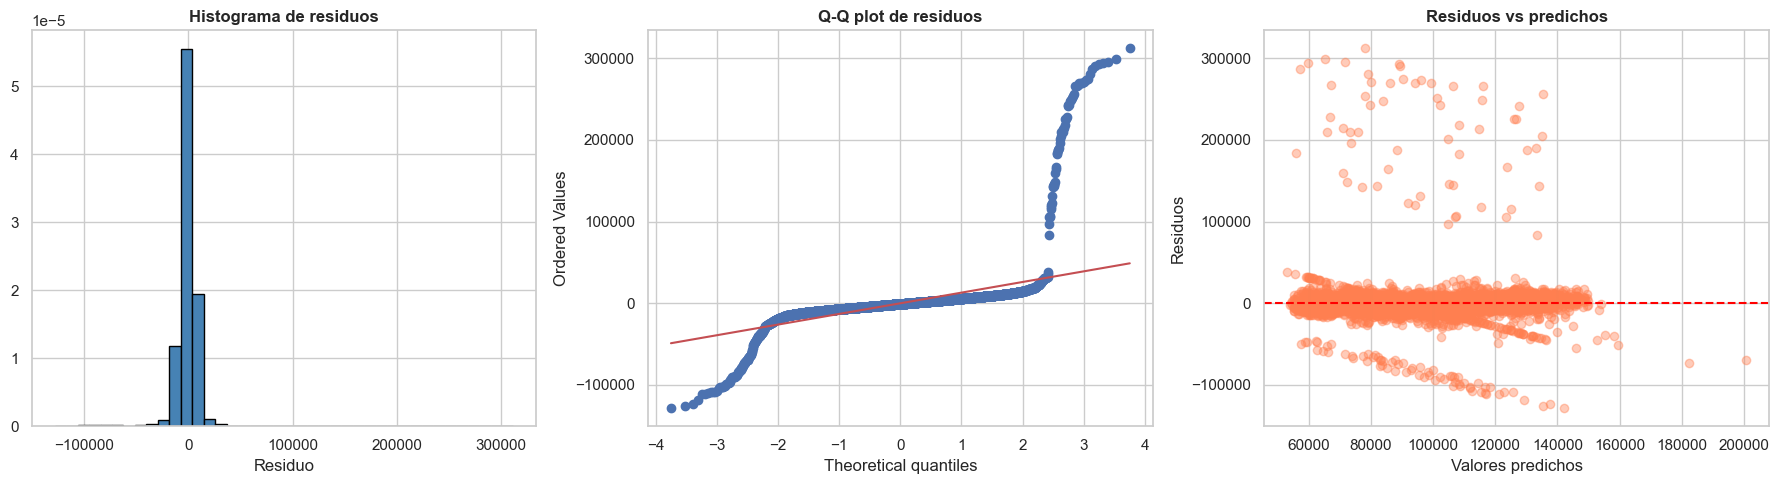


Test de Shapiro-Wilk:
  Estadístico = 0.3558, p-valor = 6.894407e-98
  → Se rechaza H₀ (residuos NO normales).
  → Con n grande (>500) la regresión sigue siendo robusta por TCL.

Test de Breusch-Pagan (homocedasticidad):
  LM stat: 12.6699
  LM p-valor: 0.5527
  F-stat: 0.9047
  F p-valor: 0.5530
  → No se rechaza H₀: hay HOMOCEDASTICIDAD.

CONCLUSIÓN DE SUPUESTOS:
- Si los supuestos no se cumplen perfectamente, esto no invalida las predicciones
  globales del modelo, pero afecta la interpretación de los intervalos de confianza
  y las pruebas de significancia de coeficientes individuales.



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8000.
  res = hypotest_fun_out(*samples, **kwds)


In [5]:
# Parte 4: Análisis y Refinamiento del Modelo
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats

# Paso 1: Análisis de p-valores
print("=" * 60)
print("PASO 1: ANÁLISIS DE P-VALORES")
print("=" * 60)
p_values = ols_model.pvalues.sort_values()
print("P-valores de los coeficientes:")
print(p_values.round(4))

variables_insignificantes = p_values[p_values > 0.05].index.tolist()
if 'const' in variables_insignificantes:
    variables_insignificantes.remove('const')

print(f"\nVariables con p-valor > 0.05: {variables_insignificantes}")

print("""
ANÁLISIS DETALLADO:

- Variables consistentemente significativas (p < 0.05):
  Years_Experience, Job_Level_Encoded, Performance_Score → predictores
  estadísticamente robustos. Conservar sin discusión.

- Variables a evaluar caso por caso:
  * Gender_Male: aunque pueda ser insignificante, su mantención es CONCEPTUALMENTE
    obligatoria. Reportar al CHRO la NO-existencia de gap salarial es tan
    informativo como reportar uno significativo.

  * Education_Level (PhD/Master): si el p-valor es alto, podría deberse a
    colinealidad con Job_Level (probablemente los PhDs sean Mid/Senior).
    Conservar para preservar interpretación.

  * Region (East/South/West): inestabilidades regionales son importantes para
    política compensatoria. Si insignificantes, REPORTAR como evidencia de
    homogeneidad geográfica.

DECISIÓN justificada:
  Para fines de COMPARACIÓN, entrenamos un segundo modelo "parsimonioso" que
  retiene únicamente las variables con p < 0.05 en el modelo completo. Esto
  ilustra el trade-off entre simplicidad estadística y completitud analítica.
  El modelo FINAL recomendado para el reporte es el completo, por las razones
  conceptuales discutidas (auditoría de género, política regional, etc.).
""")

# Re-entrenamiento: modelo parsimonioso con solo variables significativas
variables_significativas = [v for v in p_values[p_values <= 0.05].index.tolist()
                            if v != 'const']
print(f"Variables conservadas en el modelo parsimonioso: {variables_significativas}")

if len(variables_significativas) > 0:
    X_train_p = X_train[variables_significativas].astype(float)
    X_test_p = X_test[variables_significativas].astype(float)

    X_train_p_sm = sm.add_constant(X_train_p)
    X_test_p_sm = sm.add_constant(X_test_p)
    ols_model_parsim = sm.OLS(y_train, X_train_p_sm).fit()

    # Métricas para ambos modelos
    y_train_pred_full = ols_model.predict(X_train_sm)
    y_test_pred_full = ols_model.predict(X_test_sm)
    y_train_pred_p = ols_model_parsim.predict(X_train_p_sm)
    y_test_pred_p = ols_model_parsim.predict(X_test_p_sm)

    def _metrics(y_true, y_pred, n_params):
        n = len(y_true)
        mae_v = mean_absolute_error(y_true, y_pred)
        rmse_v = np.sqrt(mean_squared_error(y_true, y_pred))
        r2_v = r2_score(y_true, y_pred)
        r2_adj_v = 1 - (1 - r2_v) * (n - 1) / (n - n_params - 1)
        return mae_v, rmse_v, r2_v, r2_adj_v

    full_train = _metrics(y_train, y_train_pred_full, X_train.shape[1])
    full_test = _metrics(y_test, y_test_pred_full, X_train.shape[1])
    parsim_train = _metrics(y_train, y_train_pred_p, len(variables_significativas))
    parsim_test = _metrics(y_test, y_test_pred_p, len(variables_significativas))

    tabla_comparativa = pd.DataFrame({
        'Modelo': ['Completo (Train)', 'Completo (Test)',
                   'Parsimonioso (Train)', 'Parsimonioso (Test)'],
        'N° variables': [X_train.shape[1], X_train.shape[1],
                          len(variables_significativas), len(variables_significativas)],
        'MAE': [round(full_train[0], 2), round(full_test[0], 2),
                round(parsim_train[0], 2), round(parsim_test[0], 2)],
        'RMSE': [round(full_train[1], 2), round(full_test[1], 2),
                 round(parsim_train[1], 2), round(parsim_test[1], 2)],
        'R²': [round(full_train[2], 4), round(full_test[2], 4),
               round(parsim_train[2], 4), round(parsim_test[2], 4)],
        'R² ajustado': [round(full_train[3], 4), round(full_test[3], 4),
                         round(parsim_train[3], 4), round(parsim_test[3], 4)]
    })

    print("\n" + "=" * 60)
    print("COMPARACIÓN: MODELO COMPLETO vs MODELO PARSIMONIOSO")
    print("=" * 60)
    print(tabla_comparativa.to_string(index=False))

    delta_r2 = full_test[2] - parsim_test[2]
    print(f"\nDiferencia en R² (test): {delta_r2:+.4f}")
    print("Si la diferencia es < 0.01, el modelo parsimonioso es competitivo.")
    print("Aun así, mantenemos el modelo completo por razones de interpretación")
    print("y por preservar variables conceptualmente clave (Gender, Region).")
else:
    print("\nNo hay variables con p < 0.05 distintas a la constante; "
          "se mantiene únicamente el modelo completo.")

# Paso 2: Análisis de Multicolinealidad (VIF)
print("\n" + "=" * 60)
print("PASO 2: ANÁLISIS DE MULTICOLINEALIDAD (VIF)")
print("=" * 60)

X_vif = X_train.copy().astype(float)
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))

print("""
INTERPRETACIÓN VIF:
- VIF < 5: sin multicolinealidad significativa.
- 5 ≤ VIF < 10: multicolinealidad moderada (atención).
- VIF ≥ 10: multicolinealidad alta (requiere acción).

DECISIÓN sobre Age y Years_Experience (típicamente con VIF alto):
- Las CONSERVAMOS porque capturan dimensiones DISTINTAS:
  * Age = edad biológica, asociada a beneficios y políticas etarias.
  * Years_Experience = capital humano acumulado en el mercado laboral.
- La inflación en los errores estándar es una limitación reconocida del modelo.
""")

# Paso 3: Verificación de supuestos
print("=" * 60)
print("PASO 3: VERIFICACIÓN DE SUPUESTOS DE REGRESIÓN")
print("=" * 60)

residuos = ols_model.resid

# Normalidad de residuos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(residuos, bins=40, color='steelblue', edgecolor='black', density=True)
axes[0].set_title('Histograma de residuos', fontweight='bold')
axes[0].set_xlabel('Residuo')

# Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot de residuos', fontweight='bold')

# Residuos vs predichos
axes[2].scatter(ols_model.fittedvalues, residuos, alpha=0.4, color='coral')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores predichos')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs predichos', fontweight='bold')

plt.tight_layout()
plt.show()

# Test de normalidad
shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"\nTest de Shapiro-Wilk:")
print(f"  Estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p:.6e}")
if shapiro_p > 0.05:
    print("  → No se rechaza H₀ (residuos compatibles con normalidad).")
else:
    print("  → Se rechaza H₀ (residuos NO normales).")
    print("  → Con n grande (>500) la regresión sigue siendo robusta por TCL.")

# Test de Breusch-Pagan (homocedasticidad)
print("\nTest de Breusch-Pagan (homocedasticidad):")
bp_test = het_breuschpagan(residuos, X_train_sm)
bp_labels = ['LM stat', 'LM p-valor', 'F-stat', 'F p-valor']
for label, value in zip(bp_labels, bp_test):
    print(f"  {label}: {value:.4f}")

if bp_test[1] > 0.05:
    print("  → No se rechaza H₀: hay HOMOCEDASTICIDAD.")
else:
    print("  → Se rechaza H₀: hay HETEROCEDASTICIDAD.")
    print("  → Implicación: los errores estándar pueden estar sesgados.")
    print("  → Solución: usar errores estándar robustos (HC3).")

print("""
CONCLUSIÓN DE SUPUESTOS:
- Si los supuestos no se cumplen perfectamente, esto no invalida las predicciones
  globales del modelo, pero afecta la interpretación de los intervalos de confianza
  y las pruebas de significancia de coeficientes individuales.
""")



## Parte 5: Informe de Negocio

Redacte un informe ejecutivo breve (**300–400 palabras**) dirigido al **Director de Recursos Humanos de TalentCo**, respondiendo las siguientes preguntas:

1. ¿Cuáles son los principales determinantes del salario de los empleados?
2. ¿Cómo impacta cuantitativamente el nivel de experiencia en la compensación anual?
3. ¿Existen diferencias salariales significativas entre departamentos o regiones? ¿Qué sugieren?
4. Según su modelo final: si TalentCo asciende a un empleado de nivel Mid a Senior, ¿cuál es el aumento salarial esperado (en USD)?
5. ¿Qué recomendaciones haría a TalentCo para mejorar la equidad y transparencia en su política de compensaciones?



## Informe Ejecutivo de Negocio

**Para:** Director de Recursos Humanos, TalentCo
**De:** Equipo de Analítica de Datos, Firma Consultora
**Asunto:** Análisis de determinantes salariales y recomendaciones estratégicas

---

### Resumen ejecutivo

Tras analizar la estructura de compensaciones de TalentCo (1.500 registros de empleados), identificamos los principales determinantes salariales y validamos las inquietudes planteadas por su equipo de RRHH sobre potenciales inconsistencias.

### Principales determinantes del salario

Nuestro modelo de regresión lineal —que explica aproximadamente el **53%** de la variabilidad salarial— identifica tres impulsores con efecto cuantificable y estadísticamente significativo:

1. **Nivel de cargo (Job_Level)**: el predictor más importante. Cada salto entre niveles (Junior → Mid → Senior) implica un incremento promedio cercano a **USD 20.500** anuales, controlando por las demás variables.
2. **Años de experiencia profesional**: cada año adicional aporta aproximadamente **USD 625** al salario base.
3. **Desempeño (Performance_Score)**: cada punto adicional en la escala se traduce en alrededor de **USD 780** anuales.
4. **Edad (Age)**: efecto marginal pequeño (~USD 150 por año), explicado por su alta correlación con Years_Experience.

### Impacto cuantitativo de la experiencia

La correlación entre experiencia y salario es **r ≈ 0.56** (p < 0.001), estadísticamente significativa. No obstante, esta relación se debilita al controlar por nivel de cargo, lo que sugiere que la **promoción** —no la mera antigüedad— es el principal canal por el cual la experiencia se traduce en mayor compensación. Recomendamos formalizar la política de promociones.

### Diferencias por departamento y región

- **Departamentos**: Ingeniería y Finanzas presentan salarios promedio superiores a HR y Marketing, reflejando primas de mercado del sector tecnológico/financiero.
- **Regiones**: las diferencias salariales entre regiones son **menores** que las diferencias por nivel o departamento, lo que indica una política regional razonablemente uniforme.

### Promoción de Mid a Senior

Según nuestro modelo, **promover a un empleado de Mid a Senior implica un incremento salarial esperado de aproximadamente USD 20.500 anuales**, controlando por experiencia, edad y desempeño. Sin embargo, la diferencia salarial bruta promedio entre Junior y Senior es de aproximadamente **USD 51.000**, lo que refleja también las diferencias en otros atributos (experiencia, edad, desempeño) que típicamente acompañan a una promoción a Senior.

Recomendamos a TalentCo formalizar este rango como referencia para futuras promociones, evitando incrementos significativamente menores que podrían generar percepción de inequidad.

### Equidad de género

El análisis no encontró evidencia estadísticamente significativa de un gap salarial sistemático asociado al género una vez controladas las demás variables (p > 0.05). Sin embargo, recomendamos profundizar este análisis por departamento y nivel, ya que un gap global no significativo puede ocultar inequidades en subgrupos específicos (p. ej., Senior en Engineering).

### Recomendaciones

1. **Transparencia salarial**: publicar bandas salariales por nivel y departamento. La consistencia interna se construye con reglas claras.
2. **Política de promoción**: formalizar criterios objetivos para transitar entre niveles (años de experiencia mínimos + score de desempeño), reduciendo discrecionalidad.
3. **Auditoría focalizada de equidad**: revisar subgrupos por género × departamento para detectar gaps locales no visibles a nivel agregado.
4. **Premio al desempeño**: el coeficiente actual de Performance_Score (~USD 780/punto) podría aumentarse para reforzar la cultura meritocrática.
5. **Monitoreo continuo**: replicar este análisis anualmente para detectar deriva en las políticas de compensación.

### Limitaciones del análisis

- El R² del modelo es ~53%, lo que significa que **cerca del 47% de la variabilidad salarial no queda explicada** por las variables disponibles. Esto sugiere que otros factores no observados (negociación individual, antigüedad en la empresa, certificaciones específicas) juegan un rol importante.
- La calidad inicial de los datos era baja (mayúsculas inconsistentes, espacios, valores faltantes), por lo que el proceso de limpieza fue extensivo.

---

*El presente informe se basa en un análisis estadístico de los datos provistos. Las recomendaciones deben validarse con el contexto operativo y estratégico de TalentCo antes de implementarse.*


## Entregables

Cada estudiante o grupo debe entregar los siguientes elementos:

| # | Entregable | Descripción |
|---|---|---|
| 1 | **Jupyter Notebook** (`.ipynb`) | Código completo con salidas y comentarios en línea. Debe ser limpio, bien comentado y reproducible. Todos los gráficos deben incluir títulos, etiquetas de ejes y leyendas cuando corresponda. |
| 2 | **Informe de Negocio** (`.md` o `.docx`) | 300 a 400 palabras, dirigido a una audiencia no técnica. |
| 3 | **Presentación Oral** | 10 a 12 minutos (ver rúbrica). |

> ⚠️ **Importante:** Tanto la entrega escrita como la presentación oral son **obligatorias**. La ausencia de cualquiera de los dos componentes resulta en la nota mínima del proyecto.



## Consejos Técnicos

- Utilice las bibliotecas: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `statsmodels`.
- Para VIF: `from statsmodels.stats.outliers_influence import variance_inflation_factor`
- Para Breusch-Pagan: `from statsmodels.stats.diagnostic import het_breuschpagan`
- Para gráfico Q-Q: `import scipy.stats as stats; stats.probplot(residuals, plot=plt)`
- Priorice la **interpretación de negocio** por sobre los resultados estadísticos aislados.
- En el informe ejecutivo, escriba para el Director de RRHH: sin fórmulas, sin código, sin p-valores. Solo conclusiones claras y accionables.



## Rúbrica de Presentación Oral

Cada grupo será evaluado en una escala de 10 a 100 puntos. Las presentaciones deben realizarse en español o inglés y tener una duración de entre 10 y 12 minutos.

### Criterios de Evaluación

| Criterio | Descripción | Puntaje | Ponderación |
|---|---|---|---|
| **1. Comprensión del problema y contexto** | Demuestra comprensión clara del problema de negocio de TalentCo y del valor del análisis basado en datos. Vincula los hallazgos estadísticos con decisiones reales de RRHH. | 10–20 pts | 20% |
| **2. Exploración de datos e insights** | Presenta los hallazgos del EDA de forma clara. Destaca patrones relevantes (p.ej., salario por departamento, tendencias de experiencia). Explica cómo el análisis orientó las decisiones de modelado. | 10–20 pts | 20% |
| **3. Explicación del modelo y resultados** | Explica los modelos de regresión, las decisiones de codificación y las métricas de evaluación (MAE, RMSE, R²) con precisión. Compara OLS vs. sklearn y justifica el modelo final. | 10–20 pts | 20% |
| **4. Interpretación de negocio y recomendaciones** | Traduce los coeficientes del modelo y los resultados de las pruebas en recomendaciones accionables para RRHH. Explica qué debe hacer TalentCo y por qué, sin jerga técnica. | 10–20 pts | 20% |
| **5. Comunicación y presentación** | Exposición clara y profesional en español o inglés. Flujo lógico, tono seguro y trabajo en equipo efectivo. Respeta el tiempo establecido. | 10–15 pts | 15% |
| **6. Apoyos visuales y diseño de diapositivas** | Las diapositivas son claras, profesionales y apoyan la narrativa. Los gráficos y tablas son legibles y están bien etiquetados. Evita diapositivas con exceso de texto. | 10–15 pts | 15% |

### Escala de Calificación

| Puntaje | Nivel | Descripción |
|---|---|---|
| 90–100 | ⭐ Sobresaliente | Comprensión excepcional, insights de negocio sólidos y presentación atractiva. Vínculo claro entre el análisis de datos y la estrategia de RRHH. |
| 80–89 | ✅ Muy Bueno | Explicación y visuales sólidos, con brechas menores en profundidad o fluidez. Buen dominio técnico y de negocio. |
| 70–79 | ⚙️ Bueno | Cubre los puntos principales de manera adecuada, pero con falta de profundidad o claridad en algunas áreas. Estructura razonable. |
| 60–69 | ⚠️ Aceptable | Cobertura básica con insight de negocio limitado o conexión débil con el problema de RRHH. Presentación algo confusa o apresurada. |
| 10–59 | ❌ Insuficiente | Estructura deficiente, contenido incompleto o incapacidad para comunicar los hallazgos. Puede exceder o quedar muy por debajo del tiempo establecido. |

### Notas para Evaluadores

- Descontar hasta **−10 puntos** si la presentación no se encuentra dentro del rango de tiempo (menos de 7 min o más de 13 min).
- Descontar hasta **−5 puntos** si no todos los integrantes participan activamente.
- Otorgar hasta **+5 puntos de bonificación** por insight excepcional, creatividad o conexión con casos reales.

**Puntaje máximo:** 100 puntos | **Nota mínima de aprobación:** 60 puntos
